Helper code for visualising solutions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import itertools as it
import random
import statistics
%matplotlib inline
random.seed(57)
#Map of Europe
europe_map = plt.imread('map.png')

#Lists of city coordinates
city_coords = {
    "Barcelona": [2.154007, 41.390205], "Belgrade": [20.46, 44.79], "Berlin": [13.40, 52.52], 
    "Brussels": [4.35, 50.85], "Bucharest": [26.10, 44.44], "Budapest": [19.04, 47.50],
    "Copenhagen": [12.57, 55.68], "Dublin": [-6.27, 53.35], "Hamburg": [9.99, 53.55], 
    "Istanbul": [28.98, 41.02], "Kyiv": [30.52, 50.45], "London": [-0.12, 51.51], 
    "Madrid": [-3.70, 40.42], "Milan": [9.19, 45.46], "Moscow": [37.62, 55.75],
    "Munich": [11.58, 48.14], "Paris": [2.35, 48.86], "Prague": [14.42, 50.07],
    "Rome": [12.50, 41.90], "Saint Petersburg": [30.31, 59.94], "Sofia": [23.32, 42.70],
    "Stockholm": [18.06, 60.33], "Vienna": [16.36, 48.21], "Warsaw": [21.02, 52.24]}

In [2]:
#Helper code for plotting plans
#First, visualizing the cities.
import csv
with open("european_cities.csv", "r") as f:
    data = list(csv.reader(f, delimiter=';'))
    cities = data[0]
    distanceMatrix = data[1:] #rest of the csv-file
# print(cities)
# print(distanceMatrix)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(europe_map, extent=[-14.56, 38.43, 37.697 + 0.3, 64.344 + 2.0], aspect="auto")
# Map (long, lat) to (x, y) for plotting
for city, location in city_coords.items():
    x, y = (location[0], location[1])
    plt.plot(x, y, 'ok', markersize=5)
    plt.text(x, y, city, fontsize=12)

In [3]:
#A method you can use to plot your plan on the map.
def plot_plan(city_order):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(europe_map, extent=[-14.56, 38.43, 37.697 + 0.3, 64.344 + 2.0], aspect="auto")

    # Map (long, lat) to (x, y) for plotting
    for index in range(len(city_order) - 1):
        current_city_coords = city_coords[city_order[index]]
        next_city_coords = city_coords[city_order[index+1]]
        x, y = current_city_coords[0], current_city_coords[1]
        #Plotting a line to the next city
        next_x, next_y = next_city_coords[0], next_city_coords[1]
        plt.plot([x, next_x], [y, next_y])

        plt.plot(x, y, 'ok', markersize=5)
        plt.text(x, y, index, fontsize=12)
    #Finally, plotting from last to first city
    first_city_coords = city_coords[city_order[0]]
    first_x, first_y = first_city_coords[0], first_city_coords[1]
    plt.plot([next_x, first_x], [next_y, first_y])
    #Plotting a marker and index for the final city
    plt.plot(next_x, next_y, 'ok', markersize=5)
    plt.text(next_x, next_y, index+1, fontsize=12)
    plt.show()

shortest path with 6 cities:
['Barcelona', 'Belgrade', 'Bucharest', 'Budapest', 'Berlin', 'Brussels']
Shortest distance: 5018.81km



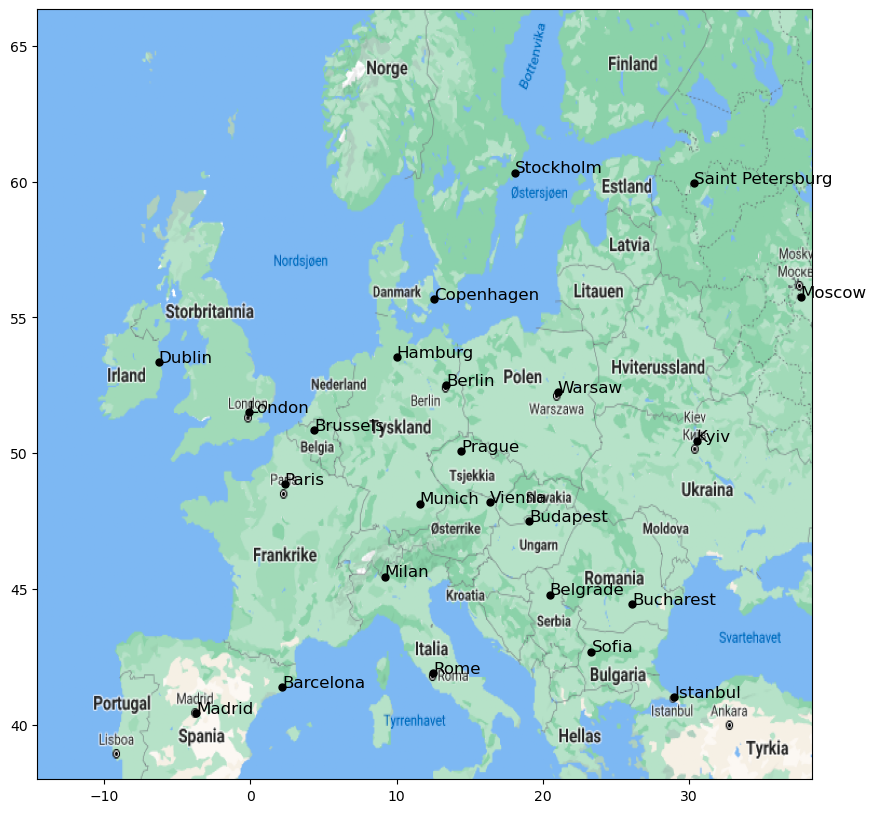

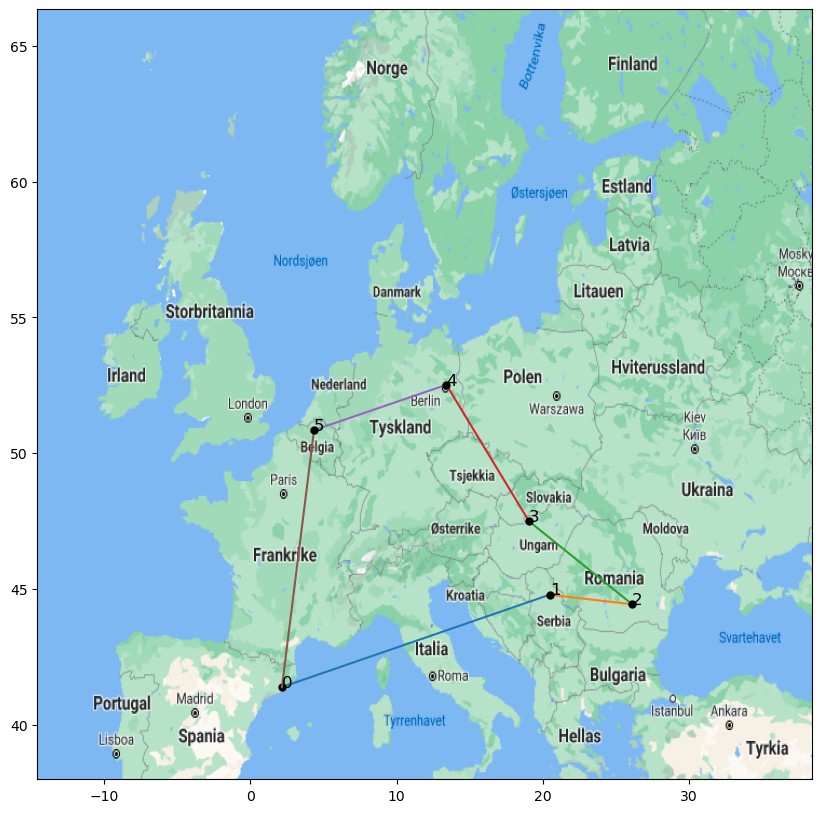

shortest path with 10 cities:
['Copenhagen', 'Hamburg', 'Brussels', 'Dublin', 'Barcelona', 'Belgrade', 'Istanbul', 'Bucharest', 'Budapest', 'Berlin']
Shortest distance: 7486.31km



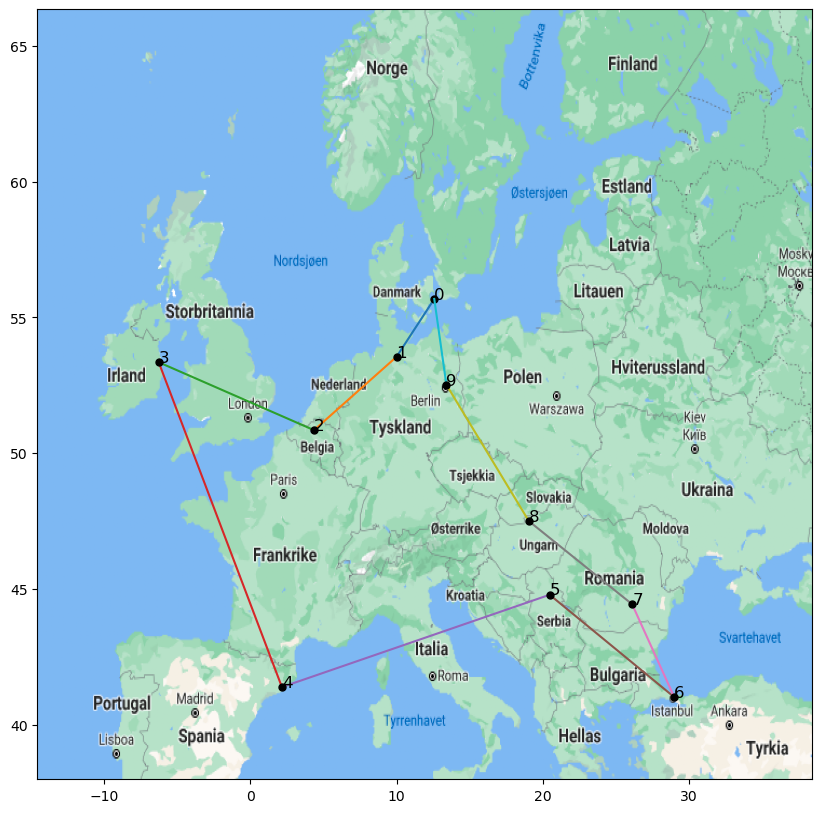

In [4]:
#Exhaustive search method

def getDistance(distanceMatrix, from_city: int, to_city: int):
    return float(distanceMatrix[from_city][to_city])

def getRoundtrip(distanceMatrix, cityIndexesOrdered): #
    totalDistance = 0
    for i in range(len(cityIndexesOrdered)-1):
        from_city = cityIndexesOrdered[i]
        to_city = cityIndexesOrdered[i+1]
        totalDistance += getDistance(distanceMatrix, from_city, to_city)
    totalDistance += getDistance(distanceMatrix, cityIndexesOrdered[-1], cityIndexesOrdered[0])

    return totalDistance

def pathIndexToStr(pathIndexed, cities):
    path = []
    for index in pathIndexed:
        city = cities[index]
        path.append(city)
    return path

def TSP_Exhaustive(distanceMatrix, cities, whichCities, numeric = False): #Calculates all possible roundtrips between n cities and returns the shortest path
    shortestPath = []
    shortestDistance = 1000000.0
    permutations = list(it.permutations(whichCities)) #all possible paths
    
    for path in permutations:
        roundtrip = getRoundtrip(distanceMatrix, path)
        if roundtrip < shortestDistance:
            shortestDistance = roundtrip
            shortestPath = path
    
    if numeric:
        return [shortestPath, shortestDistance]
    return [pathIndexToStr(shortestPath, cities), shortestDistance]

def testTSPExhaustive(n, reportResults):
    ncities = [i for i in range(n)]
    result = TSP_Exhaustive(distanceMatrix, cities, ncities)
    if reportResults:
        print(f"shortest path with {n} cities:\n{result[0]}\nShortest distance: {result[1]:.2f}km\n")
    plot_plan(result[0])

testTSPExhaustive(6, True)
testTSPExhaustive(10, True)

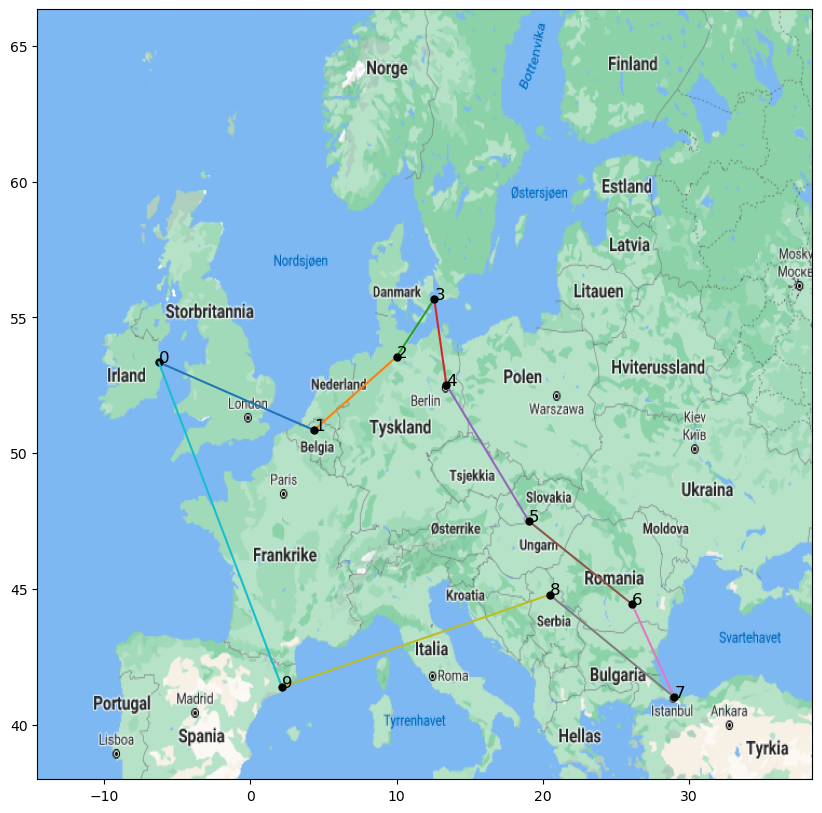

shortest path with 10 cities, 20 runs:
['Dublin', 'Brussels', 'Hamburg', 'Copenhagen', 'Berlin', 'Budapest', 'Bucharest', 'Istanbul', 'Belgrade', 'Barcelona']
Diagnostic data:
Best-run = 7486.31km | Worst run = 8377.24km
Mean (avg) run = 7667.67km | Standard deviation = 268.947



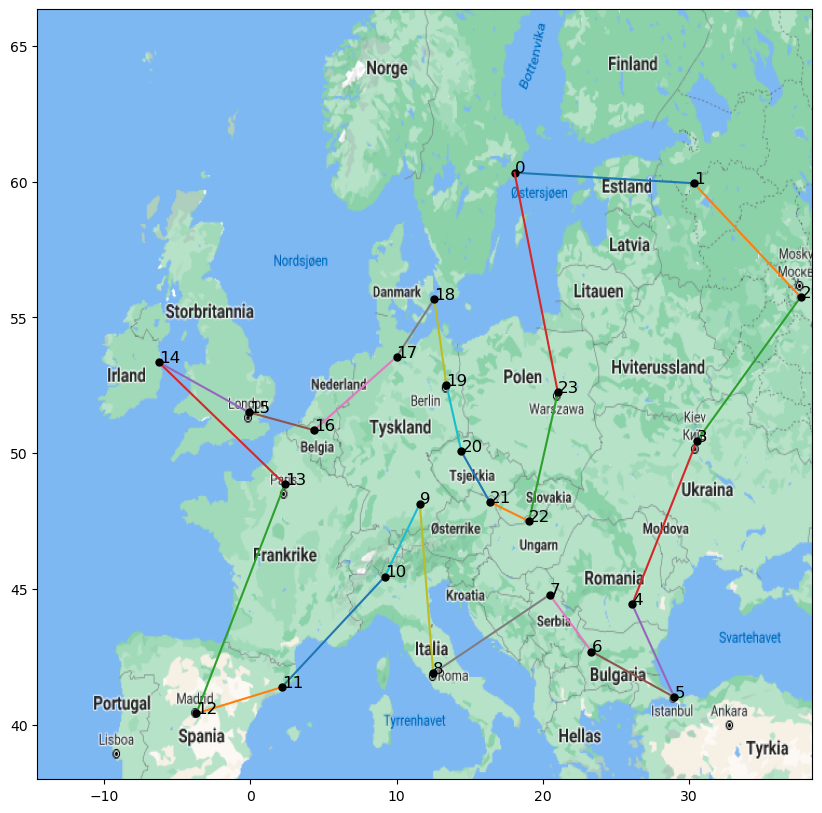

shortest path with 24 cities, 20 runs:
['Stockholm', 'Saint Petersburg', 'Moscow', 'Kyiv', 'Bucharest', 'Istanbul', 'Sofia', 'Belgrade', 'Rome', 'Munich', 'Milan', 'Barcelona', 'Madrid', 'Paris', 'Dublin', 'London', 'Brussels', 'Hamburg', 'Copenhagen', 'Berlin', 'Prague', 'Vienna', 'Budapest', 'Warsaw']
Diagnostic data:
Best-run = 12942.67km | Worst run = 15769.53km
Mean (avg) run = 14555.21km | Standard deviation = 753.889



In [5]:
# help functions
def swap(lst, pair):
    i = lst.index(pair[0])
    j = lst.index(pair[1])
    lst[i], lst[j] = lst[j], lst[i]
    return lst

def updateDiagnostics(distances, individuals = []):
    best = min(distances)
    worst = max(distances)
    ix = distances.index(best)
    i = -1
    for value in distances:
        i += 1
        if value < best:
            best = value
            ix = i
        if value > worst:
            worst = value

    bestPath = None
    if len(individuals) > 0:        
        bestPath = individuals[ix]    

    mean = sum(distances)/len(distances)
    stdev = statistics.stdev(distances)
    return {"bestPath" : bestPath, "best" : best, "worst" : worst, "mean" : mean, "stdev" : stdev}

def hillClimb(distanceMatrix, cities, whichCities):
    #Initializing
    bestPath = whichCities.copy()
    random.shuffle(bestPath)
    bestDistance = getRoundtrip(distanceMatrix, bestPath)
    neighbourMatrix = list(it.combinations(bestPath,2))

    #stop loop if no improvements 10 times successive
    limit = 10
    numGens = 0
    while limit > 0:
        improved = False
        for pair in neighbourMatrix:
            swappedPath = swap(bestPath.copy(), pair)
            swappedDistance = getRoundtrip(distanceMatrix, swappedPath)
            if swappedDistance < bestDistance:
                bestPath = swappedPath
                bestDistance = swappedDistance
                improved = True
        numGens += 1
        if improved == False:
            limit -= 1
    return bestPath, bestDistance


def hillClimbFull(distanceMatrix, cities, whichCities, n, diagnostics = False):
    bestPath = []
    bestDistance = 1000000
    distanceResults = []

    for i in range(n):
        currentPath, currentDistance = hillClimb(distanceMatrix, cities, whichCities)
        distanceResults.append(currentDistance)
        if currentDistance < bestDistance:
            bestPath = currentPath
            bestDistance = currentDistance
    
    if diagnostics:
        diag : dict = updateDiagnostics(distanceResults)
        return [bestPath, diag]
    
    return [bestPath, bestDistance]

def testHillclimb(n, shareDiagnostics = True, sharePlot = True):
    nCities = [i for i in range(n)]
    hillclimbResults = hillClimbFull(distanceMatrix, cities, nCities, 20, shareDiagnostics)
    bestPath = pathIndexToStr(hillclimbResults[0], cities)
    if sharePlot:
        plot_plan(bestPath)
    if shareDiagnostics:
        diag = hillclimbResults[1]
        print(f"shortest path with {n} cities, 20 runs:\n{bestPath}")
        print(f"Diagnostic data:")
        print(f"Best-run = {diag["best"]:.2f}km | Worst run = {diag["worst"]:.2f}km")
        print(f"Mean (avg) run = {diag["mean"]:.2f}km | Standard deviation = {diag["stdev"]:.3f}\n")
    else:
        return hillclimbResults

testHillclimb(10, True)
testHillclimb(24, True)

In [6]:
def plot_graph(meanHistory, label):
    plt.figure(figsize=(10, 6))
    plt.plot(meanHistory, label=label)
    plt.xlabel("Generation")
    plt.ylabel("Average best tour length (km)")
    plt.title("Best tour per generation, averaged over 20 runs")
    plt.legend()
    plt.show()

Diagnostic data:
shortest path with 24 cities, 20 runs:
['Barcelona', 'Rome', 'Milan', 'Munich', 'Prague', 'Berlin', 'Warsaw', 'Vienna', 'Budapest', 'Belgrade', 'Sofia', 'Istanbul', 'Bucharest', 'Kyiv', 'Moscow', 'Saint Petersburg', 'Stockholm', 'Copenhagen', 'Hamburg', 'Brussels', 'Paris', 'London', 'Dublin', 'Madrid']
Best-run = 12287.07km | Worst run = 12712.71km
Mean (avg) run = 12444.12km | Standard deviation = 157.744



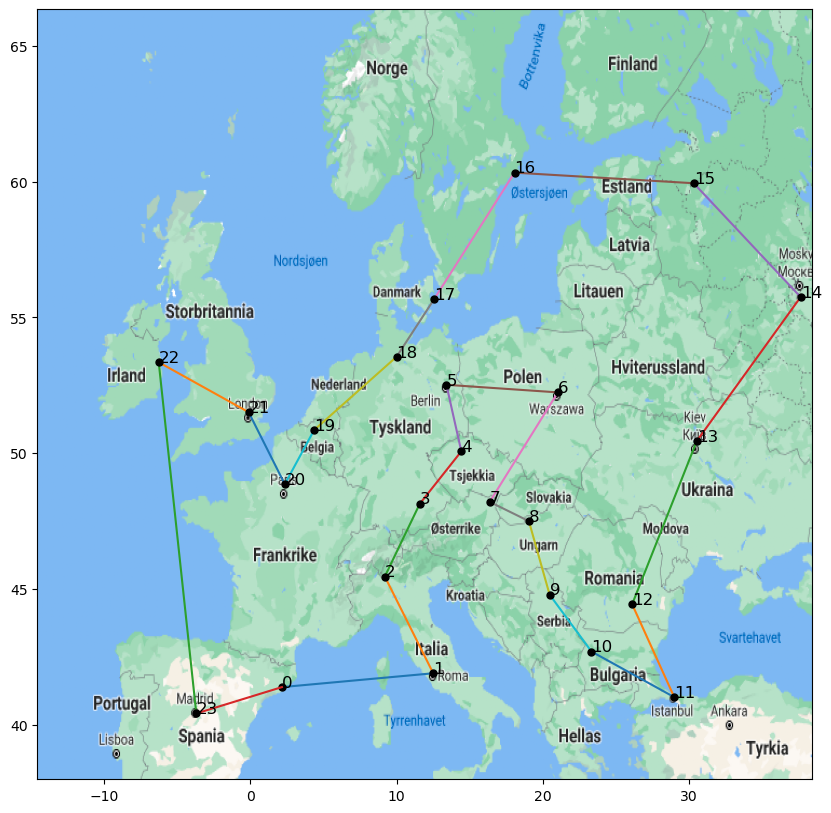

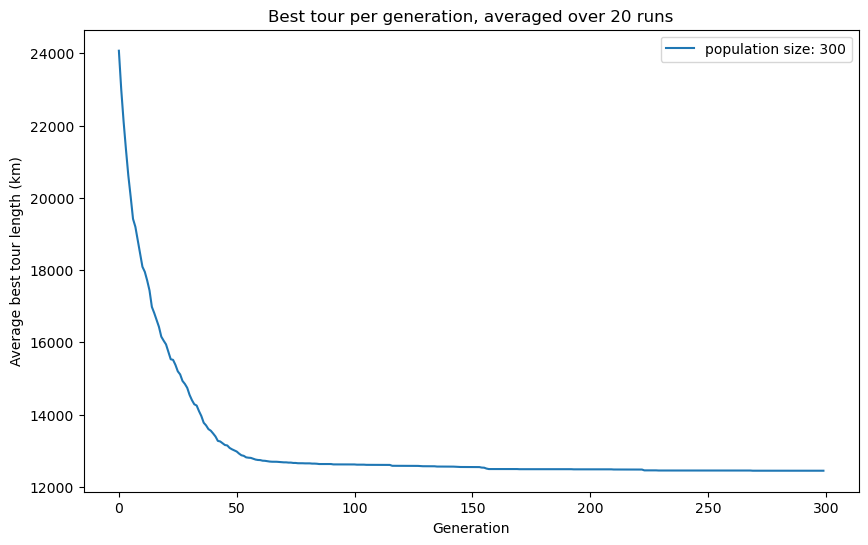

In [7]:
#evaluation: fitness (< Distance)
#Population: 100 unique solutions

def initPopulation(distanceMatrix, numCities, popSize):
    population = []
    initial = list(range(numCities))
    totalFitness = 0
    for i in range(popSize):
        random.shuffle(initial)
        shuffled = initial.copy()
        fitness = getIndividualFitness(distanceMatrix, initial)
        totalFitness += fitness
        population.append((shuffled, fitness))
    return population, totalFitness
    
def tournamentSelect(population, tournamentSize):
    # Pick tournamentSize random individuals, without picking the same one twice
    contestants = random.sample(population, tournamentSize)

    # Return the contestant with the shortest tour
    winner = contestants[0]
    for contestant in contestants:
        if contestant[1] < winner[1]:
            winner = contestant
    return winner

def selectParents(population, bestFive, num_parents):
    # findBestFive removed the elites from population, so add them back
    pool = population + bestFive

    selected_parents = []
    for _ in range(num_parents):
        winner = tournamentSelect(pool, 3)
        selected_parents.append(winner)
    return selected_parents
        

def order_crossover(p1, p2):
    size = len(p1)
    start, end = sorted(random.sample(range(size), 2))
    child = [None] * size

    # Copy a slice from p1
    child[start:end+1] = p1[start:end+1]

    # Fill remaining positions with p2's cities, preserving order and uniqueness
    p2_index = 0
    for i in range(size):
        if child[i] is None:
            while p2[p2_index] in child:
                p2_index += 1
            child[i] = p2[p2_index]
    return child

def crossOver(parents, popsize):
    offsprings = []
    for _ in range(popsize):
        p1 = random.choice(parents)[0]
        p2 = random.choice(parents)[0]
        offspring = order_crossover(p1, p2)
        offsprings.append(offspring)
    return offsprings

def inverseMutation(offsprings, mutationRate):
    for offspring in offsprings:
        if random.random() < mutationRate:
            i, j = sorted(random.sample(range(len(offspring)), 2))
            offspring[i:j+1] = offspring[i:j+1][::-1]
    return offsprings


def getIndividualFitness(distanceMatrix, path):
    return getRoundtrip(distanceMatrix, path)

def evaluate(distanceMatrix, population):
    newPop = []
    totalFitness = 0
    for individual in population:
        fitness = getIndividualFitness(distanceMatrix, individual)
        newPop.append((individual, fitness))
        totalFitness += fitness
    return newPop, totalFitness

def findBestFitIndividual(population):
    bestIndividual = 0
    bestDistance = 100000
    bestPos = 0
    i = 0
    for individual in population:
        currentDistance = individual[1]
        
        if currentDistance < bestDistance: #new best found
            bestIndividual = individual
            bestDistance = currentDistance
            bestPos = i
        i += 1
    return bestIndividual, bestPos


def findBestFive(population):
    bestFive = []
    for i in range(5):
        best, pos = findBestFitIndividual(population)
        bestFive.append(best)
        population.pop(pos)
    return bestFive

def EATSP(numCities, popsize, generations, distanceMatrix):
    population, totalFitness = initPopulation(distanceMatrix, numCities, popsize)
    #print(f"initial population fitness: {initialTotalFitness}\n")
    bestFive = findBestFive(population)
    #print("best initial individual: ", bestIndividual)

    history = []
    #print("Population: ", population)
    for generation in range(generations):

        parents = selectParents(population, bestFive, popsize//2)
        offsprings = crossOver(parents, popsize-5)
        mutatedOffsprings = inverseMutation(offsprings, 0.3) #30% mutation rate
        newPopulation, newTotalFitness = evaluate(distanceMatrix, mutatedOffsprings)
        newPopulation.extend(bestFive)
        #print("new population: ", newPopulation)
        #print("new totalFitness: ", newTotalFitness)

        population = newPopulation
        bestFive = findBestFive(population)

        bestIndividual = bestFive[0]
        history.append(bestIndividual[1])

    return bestIndividual, history


def testEATSP(numCities, popsize, n, generations, sharePlot = True, diagnostics = True, graph = True):
    paths = []
    distances = []

    histories = []
    for i in range(n):
        bestIndividual, history = EATSP(numCities, popsize, generations, distanceMatrix)
        paths.append(bestIndividual[0])
        distances.append(bestIndividual[1])
        histories.append(history)
    diag = updateDiagnostics(distances, paths)
    pathFinal = pathIndexToStr(diag["bestPath"], cities)  
    meanHistory = np.mean(histories, axis=0)  
    # print("distances: ", distances)
    # print("paths: ", paths)

    if diagnostics:
        print(f"Diagnostic data:")
        print(f"shortest path with {numCities} cities, {n} runs:\n{pathFinal}")
        print(f"Best-run = {diag["best"]:.2f}km | Worst run = {diag["worst"]:.2f}km")
        print(f"Mean (avg) run = {diag["mean"]:.2f}km | Standard deviation = {diag["stdev"]:.3f}\n")
    if sharePlot:
        plot_plan(pathFinal)
    if graph:
        plot_graph(meanHistory, f"population size: {popsize}")

# testEATSP(10, 300, n = 20, sharePlot = False)

testEATSP(24, 300, n = 20, generations = 300)